# Importacion de librerias y conexión

In [370]:
import mysql.connector
import pandas as pd
import numpy as np
import regex as re
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [371]:
import os
import pandas as pd

# --------------------------
# Configuración
# --------------------------
CARPETA = r"C:\Users\Usuario\ProjecteData\Equip_19\Data\INE"

# --------------------------
# Funciones
# --------------------------
def extraer_año(nombre):
    import re
    m = re.search(r'(\d{4})', nombre)
    return int(m.group(1)) if m else None

def renombrar_columnas_criticas(df):
    """
    Unifica nombres de columnas críticas sin tocar los valores.
    """
    col_map = {}
    for c in df.columns:
        cn = str(c).lower()
        if "provinc" in cn:
            col_map[c] = "provincia"
        elif ("pais" in cn and "resid" in cn) or ("residencia" in cn):
            col_map[c] = "pais_residencia"
        elif "mes" in cn:
            col_map[c] = "mes"
        elif "total" in cn or "viajer" in cn or "pernoct" in cn:
            col_map[c] = "total"
    df = df.rename(columns=col_map)
    return df

def leer_csv(ruta):
    for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        try:
            df = pd.read_csv(ruta, sep=";", encoding=enc, engine="python")
            # Normalizar miles con coma a float
            for col in df.columns:
                if df[col].dtype == object:
                    df[col] = df[col].str.replace(".", "", regex=False)\
                                     .str.replace(",", ".", regex=False)
            return df
        except:
            continue
    raise ValueError(f"No se pudo leer {ruta}")

# --------------------------
# 1) PROCESAR HOTELES
# --------------------------
hoteles_perno = []
hoteles_viaj = []

for archivo in os.listdir(CARPETA):
    ruta = os.path.join(CARPETA, archivo)
    if not archivo.lower().endswith(".csv"):
        continue
    anio = extraer_año(archivo)
    df = leer_csv(ruta)
    df = renombrar_columnas_criticas(df)

    # asegurar columnas críticas
    for c in ["provincia","pais_residencia","mes","total"]:
        if c not in df.columns:
            df[c] = pd.NA
    df["año"] = anio

    if "hoteles_pernoctaciones" in archivo.lower():
        df["pernoctaciones"] = pd.to_numeric(df["total"], errors="coerce")
        df_hot = df[["año","mes","provincia","pais_residencia","pernoctaciones"]].copy()
        hoteles_perno.append(df_hot)
    elif "hoteles_viajeros" in archivo.lower():
        df["total_viajeros"] = pd.to_numeric(df["total"], errors="coerce")
        df_hotv = df[["año","mes","provincia","pais_residencia","total_viajeros"]].copy()
        hoteles_viaj.append(df_hotv)

# unir hoteles pernoctaciones y viajeros
if hoteles_perno:
    df_hoteles = pd.concat(hoteles_perno, ignore_index=True)
    if hoteles_viaj:
        df_hoteles = df_hoteles.merge(
            pd.concat(hoteles_viaj, ignore_index=True),
            on=["año","mes","provincia","pais_residencia"],
            how="left"
        )
    df_hoteles["tipo_acomodacion"] = "hoteles"
else:
    df_hoteles = pd.DataFrame(columns=["año","mes","provincia","pais_residencia","pernoctaciones","total_viajeros","tipo_acomodacion"])

# --------------------------
# 2) PROCESAR APARTAMENTOS
# --------------------------
apart_viaj = []

for archivo in os.listdir(CARPETA):
    ruta = os.path.join(CARPETA, archivo)
    if not archivo.lower().endswith(".csv"):
        continue
    if "apartamentos_viajeros" not in archivo.lower():
        continue
    anio = extraer_año(archivo)
    df = leer_csv(ruta)
    df = renombrar_columnas_criticas(df)

    # asegurar columnas críticas
    for c in ["provincia","pais_residencia","mes","total"]:
        if c not in df.columns:
            df[c] = pd.NA
    df["año"] = anio
    apart_viaj.append(df)

if apart_viaj:
    df_apart = pd.concat(apart_viaj, ignore_index=True)
    df_apart["total_viajeros"] = pd.to_numeric(df_apart["total"], errors="coerce")
    df_apart["tipo_acomodacion"] = "apartamentos"

    # calcular la media de pernoctaciones solo si hay total_viajeros
    df_apart["pernoctaciones"] = df_apart.groupby(["año","mes","provincia"])["total_viajeros"]\
        .transform(lambda x: round(x.mean(),2) if x.notna().any() else pd.NA)

    # poner NA donde total_viajeros es NA
    df_apart.loc[df_apart["total_viajeros"].isna(), "pernoctaciones"] = pd.NA

    df_apart = df_apart[["año","mes","provincia","pais_residencia","pernoctaciones","total_viajeros","tipo_acomodacion"]]
else:
    df_apart = pd.DataFrame(columns=["año","mes","provincia","pais_residencia","pernoctaciones","total_viajeros","tipo_acomodacion"])

# --------------------------
# 3) UNIR TODO
# --------------------------
df_final = pd.concat([df_hoteles, df_apart], ignore_index=True)
columnas_finales = ["año","mes","tipo_acomodacion","provincia","pais_residencia","pernoctaciones","total_viajeros"]
df_final = df_final[columnas_finales]

# --------------------------
# 4) RESULTADO
# --------------------------
print(df_final.head())
print(df_final.isnull().sum())


    año      mes tipo_acomodacion       provincia       pais_residencia  \
0  2015    Enero          hoteles  Balears. Illes  Residentes en España   
1  2015  Febrero          hoteles  Balears. Illes  Residentes en España   
2  2015    Marzo          hoteles  Balears. Illes  Residentes en España   
3  2015    Abril          hoteles  Balears. Illes  Residentes en España   
4  2015     Mayo          hoteles  Balears. Illes  Residentes en España   

  pernoctaciones  total_viajeros  
0           2.34         21058.0  
1           3.75         48484.0  
2           4.76         64934.0  
3           4.56        107273.0  
4           3.41        123634.0  
año                    0
mes                    0
tipo_acomodacion       0
provincia              0
pais_residencia        0
pernoctaciones      1882
total_viajeros      2470
dtype: int64


In [372]:
df_final

,año,mes,tipo_acomodacion,provincia,pais_residencia,pernoctaciones,total_viajeros
0,2015,Enero,hoteles,Balears. Illes,Residentes en España,2.34,21058.0
1,2015,Febrero,hoteles,Balears. Illes,Residentes en España,3.75,48484.0
2,2015,Marzo,hoteles,Balears. Illes,Residentes en España,4.76,64934.0
3,2015,Abril,hoteles,Balears. Illes,Residentes en España,4.56,107273.0
4,2015,Mayo,hoteles,Balears. Illes,Residentes en España,3.41,123634.0
...,...,...,...,...,...,...,...
16459,2021,Agosto,apartamentos,46 Valencia/València,Resto del mundo,14828.23,1408.0
16460,2021,Septiembre,apartamentos,46 Valencia/València,Resto del mundo,6636.69,1257.0
16461,2021,Octubre,apartamentos,46 Valencia/València,Resto del mundo,4933.08,1087.0
16462,2021,Noviembre,apartamentos,46 Valencia/València,Resto del mundo,3173.0,1279.0


In [373]:
df_final.isnull().sum()

año                    0
mes                    0
tipo_acomodacion       0
provincia              0
pais_residencia        0
pernoctaciones      1882
total_viajeros      2470
dtype: int64

In [374]:
df_final

,año,mes,tipo_acomodacion,provincia,pais_residencia,pernoctaciones,total_viajeros
0,2015,Enero,hoteles,Balears. Illes,Residentes en España,2.34,21058.0
1,2015,Febrero,hoteles,Balears. Illes,Residentes en España,3.75,48484.0
2,2015,Marzo,hoteles,Balears. Illes,Residentes en España,4.76,64934.0
3,2015,Abril,hoteles,Balears. Illes,Residentes en España,4.56,107273.0
4,2015,Mayo,hoteles,Balears. Illes,Residentes en España,3.41,123634.0
...,...,...,...,...,...,...,...
16459,2021,Agosto,apartamentos,46 Valencia/València,Resto del mundo,14828.23,1408.0
16460,2021,Septiembre,apartamentos,46 Valencia/València,Resto del mundo,6636.69,1257.0
16461,2021,Octubre,apartamentos,46 Valencia/València,Resto del mundo,4933.08,1087.0
16462,2021,Noviembre,apartamentos,46 Valencia/València,Resto del mundo,3173.0,1279.0


## Tratamiento de nulos

In [375]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16464 entries, 0 to 16463
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   año               16464 non-null  int64  
 1   mes               16464 non-null  object 
 2   tipo_acomodacion  16464 non-null  object 
 3   provincia         16464 non-null  object 
 4   pais_residencia   16464 non-null  object 
 5   pernoctaciones    14582 non-null  object 
 6   total_viajeros    13994 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 900.5+ KB


In [376]:
df_final.isnull().sum()

año                    0
mes                    0
tipo_acomodacion       0
provincia              0
pais_residencia        0
pernoctaciones      1882
total_viajeros      2470
dtype: int64

## Estandarización de texto

In [377]:
from rapidfuzz import fuzz

datosp = sorted([str(x) for x in df_final["provincia"].unique()])

for i in range(len(datosp)):
    for j in range(i+1, len(datosp)):
        score = fuzz.ratio(datosp[i], datosp[j])
        if score > 85:
            print(f"{score:.1f}% - '{datosp[i]}' vs '{datosp[j]}'")


90.3% - '07 Balears. Illes' vs 'Balears. Illes'
85.7% - '08 Barcelona' vs 'Barcelona'
91.9% - '46 Valencia/València' vs 'Valencia/València'
86.5% - '46 Valencia/València' vs 'Valencia/Valéncia'
94.1% - 'Valencia/València' vs 'Valencia/Valéncia'


In [378]:
df_final["provincia"] = df_final["provincia"].replace(['Balears, Illes', '07 Balears, Illes'], 'Islas Baleares').replace('08 Barcelona', 'Barcelona').replace([
    "46 Valencia/València","Valencia/València","Valencia/Valéncia"], "Valencia").replace('17 Girona', 'Girona').replace('28 Madrid', 'Madrid').replace(
        '41 Sevilla', 'Sevilla').replace('29 Málaga', 'Málaga')

In [379]:
df_final["provincia"].unique()

array(['Balears. Illes', 'Barcelona', 'Girona', 'Madrid', 'Málaga',
       'Sevilla', 'Valencia', '07 Balears. Illes'], dtype=object)

In [380]:
datosta = sorted([str(x) for x in df_final["tipo_acomodacion"].unique()])

for i in range(len(datosta)):
    for j in range(i+1, len(datosta)):
        score = fuzz.ratio(datosta[i], datosta[j])
        if score > 85:
            print(f"{score:.1f}% - '{datosta[i]}' vs '{datosta[j]}'")

In [381]:
df_final.columns

Index(['año', 'mes', 'tipo_acomodacion', 'provincia', 'pais_residencia',
       'pernoctaciones', 'total_viajeros'],
      dtype='object')

In [382]:
df_final["tipo_acomodacion"].unique()

array(['hoteles', 'apartamentos'], dtype=object)

In [383]:
datospr = sorted([str(x) for x in df_final["pais_residencia"].unique()])

for i in range(len(datospr)):
    for j in range(i+1, len(datospr)):
        score = fuzz.ratio(datospr[i], datospr[j])
        if score > 85:
            print(f"{score:.1f}% - '{datospr[i]}' vs '{datospr[j]}'")

88.4% - 'No residentes en España' vs 'Residentes en España'


In [384]:
df_final["pais_residencia"] = df_final["pais_residencia"].replace('Países Africanos', 'Países africanos').replace('Republica Checa', 'República Checa').replace(
    ['Residentes en España', 'Españoles'], 'España'
)

In [385]:
df_final["pais_residencia"].unique()

array(['España', 'No residentes en España', 'Alemania', 'Austria',
       'Bélgica', 'Dinamarca', 'Finlandia', 'Francia', 'Grecia',
       'Irlanda', 'Italia', 'Luxemburgo', 'Países Bajos', 'Polonia',
       'Portugal', 'Reino Unido', 'República Checa', 'Suecia',
       'Resto de la UE', 'Noruega', 'Rusia', 'Suiza', 'Resto de Europa',
       'Estados Unidos', 'Resto de América', 'Países africanos',
       'Resto del mundo'], dtype=object)

In [386]:
df_final

,año,mes,tipo_acomodacion,provincia,pais_residencia,pernoctaciones,total_viajeros
0,2015,Enero,hoteles,Balears. Illes,España,2.34,21058.0
1,2015,Febrero,hoteles,Balears. Illes,España,3.75,48484.0
2,2015,Marzo,hoteles,Balears. Illes,España,4.76,64934.0
3,2015,Abril,hoteles,Balears. Illes,España,4.56,107273.0
4,2015,Mayo,hoteles,Balears. Illes,España,3.41,123634.0
...,...,...,...,...,...,...,...
16459,2021,Agosto,apartamentos,Valencia,Resto del mundo,14828.23,1408.0
16460,2021,Septiembre,apartamentos,Valencia,Resto del mundo,6636.69,1257.0
16461,2021,Octubre,apartamentos,Valencia,Resto del mundo,4933.08,1087.0
16462,2021,Noviembre,apartamentos,Valencia,Resto del mundo,3173.0,1279.0


In [387]:
# ¿Qué hacemos con "Resto de la UE", "Resto de Europa" y "Resto de Europa sin U.E"?

In [388]:
filtro = ["Resto de la UE", "Resto de Europa", "Resto de Europa sin U.E"]

df_filtrado = df_final[df_final["pais_residencia"].isin(filtro)]

print(df_filtrado["pais_residencia"].unique())
df_filtrado

['Resto de la UE' 'Resto de Europa']


,año,mes,tipo_acomodacion,provincia,pais_residencia,pernoctaciones,total_viajeros
1380,2015,Enero,apartamentos,Balears. Illes,Resto de la UE,193.05,39.0
1381,2015,Febrero,apartamentos,Balears. Illes,Resto de la UE,<NA>,NaN
1382,2015,Marzo,apartamentos,Balears. Illes,Resto de la UE,<NA>,NaN
1383,2015,Abril,apartamentos,Balears. Illes,Resto de la UE,1391.46,151.0
1384,2015,Mayo,apartamentos,Balears. Illes,Resto de la UE,5595.04,957.0
...,...,...,...,...,...,...,...
16411,2021,Agosto,apartamentos,Valencia,Resto de Europa,14828.23,1426.0
16412,2021,Septiembre,apartamentos,Valencia,Resto de Europa,6636.69,3690.0
16413,2021,Octubre,apartamentos,Valencia,Resto de Europa,4933.08,2664.0
16414,2021,Noviembre,apartamentos,Valencia,Resto de Europa,3173.0,775.0


In [389]:
for archivo in os.listdir(CARPETA):
    if archivo.lower().endswith(".csv") and "hoteles_pernoctaciones" in archivo.lower():
        df = leer_csv(os.path.join(CARPETA, archivo))
        print(f"{archivo}: {df.columns.tolist()}")

hoteles_pernoctaciones_2015.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2016.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2017.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2018.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2019.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2020.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2021.csv: ['Provincias', 'Residencia', 'Meses', 'Total']


In [390]:
df_filtrado = df_final[
    (df_final["año"] == 2015) &
    (df_final["provincia"].str.contains("Islas Baleares", case=False, na=False))
][["año","provincia","pernoctaciones","total_viajeros"]]

df_filtrado


,año,provincia,pernoctaciones,total_viajeros


In [391]:
filtro_calendario = ['Barcelona','Madrid','Valencia']
df_calendario = df_final[df_final['provincia'].isin(filtro_calendario)]
df_calendario.head(50)

,año,mes,tipo_acomodacion,provincia,pais_residencia,pernoctaciones,total_viajeros
24,2015,Enero,hoteles,Barcelona,España,1.77,198213.0
25,2015,Febrero,hoteles,Barcelona,España,1.76,210775.0
26,2015,Marzo,hoteles,Barcelona,España,1.99,256926.0
27,2015,Abril,hoteles,Barcelona,España,2.22,249647.0
28,2015,Mayo,hoteles,Barcelona,España,2.03,309483.0
29,2015,Junio,hoteles,Barcelona,España,1.99,285671.0
30,2015,Julio,hoteles,Barcelona,España,2.14,282514.0
31,2015,Agosto,hoteles,Barcelona,España,2.39,255400.0
32,2015,Septiembre,hoteles,Barcelona,España,2.05,253984.0
33,2015,Octubre,hoteles,Barcelona,España,1.89,300754.0


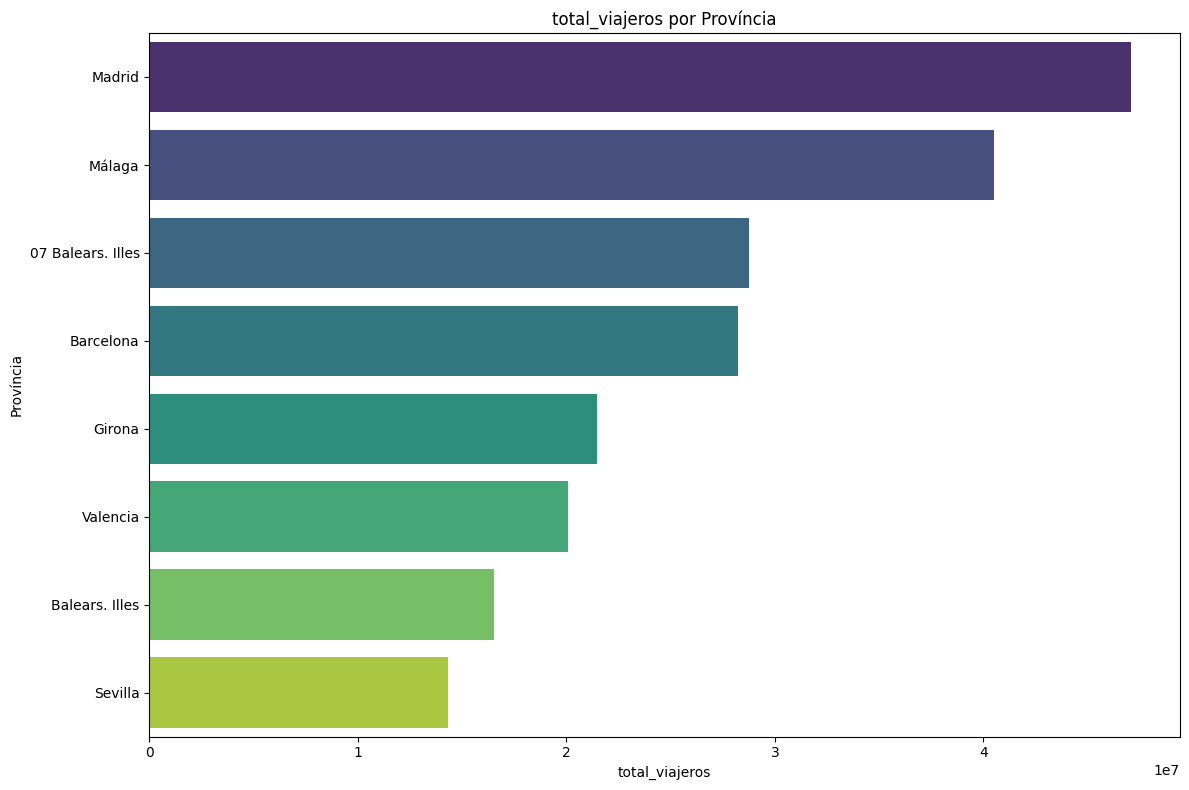

In [392]:
import seaborn as sns

colunas_requeridas = ['provincia', 'pais_residencia', 'pernoctaciones', 'total_viajeros']
for col in colunas_requeridas:
    if col not in df_final.columns:
        print(f"Erro: Coluna '{col}' não encontrada no df_final.")

# Gráfico 1: Distribuição de Pernoctações por Província
pernoctaciones_por_provincia = df_final.groupby('provincia')['total_viajeros'].sum().reset_index()
pernoctaciones_por_provincia = pernoctaciones_por_provincia.dropna(subset=['total_viajeros'])
pernoctaciones_por_provincia['total_viajeros'] = pd.to_numeric(pernoctaciones_por_provincia['total_viajeros'], errors='coerce')
pernoctaciones_por_provincia = pernoctaciones_por_provincia.dropna(subset=['total_viajeros'])
pernoctaciones_por_provincia = pernoctaciones_por_provincia.sort_values(by='total_viajeros', ascending=False)

# Criar o gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(data=pernoctaciones_por_provincia, x='total_viajeros', y='provincia', palette='viridis')
plt.title('total_viajeros por Província')
plt.xlabel('total_viajeros')
plt.ylabel('Província')
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

___________________________________________

__________________________________________________________